In [3]:
# ===== 1. 导入所需库 =====
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from transformers import Sam3Model, Sam3Processor
from quadrilateral_fitter import QuadrilateralFitter
from scipy.spatial import ConvexHull
from modelscope import snapshot_download
import tqdm

# 下载并加载 SAM3 模型
model_dir = snapshot_download('facebook/sam3', cache_dir='./sam3_model')
device = "cuda" if torch.cuda.is_available() else "cpu"
model_dir = "./sam3_model/facebook/sam3"

model = Sam3Model.from_pretrained(model_dir).to(device)
processor = Sam3Processor.from_pretrained(model_dir)

print(f"设备: {device}")


KeyboardInterrupt: 

In [2]:
# ===== 工具函数 =====
def _points_inside_quad(points, quad):
    """叉积法判断点是否在凸四边形内部"""
    pts, q = np.asarray(points, dtype=np.float64), np.asarray(quad, dtype=np.float64)
    signed_area = sum(q[i,0]*q[(i+1)%4,1] - q[(i+1)%4,0]*q[i,1] for i in range(4))
    is_cw = signed_area > 0
    inside = np.ones(len(pts), dtype=bool)
    for i in range(4):
        p1, p2 = q[i], q[(i+1)%4]
        dx, dy = p2[0]-p1[0], p2[1]-p1[1]
        cross = dx*(pts[:,1]-p1[1]) - dy*(pts[:,0]-p1[0])
        inside &= (cross >= 0) if is_cw else (cross <= 0)
    return inside

def _shrink_quad(vertices, factor=0.03):
    """沿对角线收缩四边形"""
    c = np.asarray(vertices, dtype=np.float64).mean(axis=0)
    return np.asarray(vertices) + factor * (c - vertices)

def _rectify_quality(vertices):
    """评估矫正质量"""
    w_top = np.linalg.norm(vertices[1]-vertices[0])
    w_bot = np.linalg.norm(vertices[2]-vertices[3])
    h_left = np.linalg.norm(vertices[3]-vertices[0])
    h_right = np.linalg.norm(vertices[2]-vertices[1])
    w_r = min(w_top,w_bot)/max(w_top,w_bot)
    h_r = min(h_left,h_right)/max(h_left,h_right)
    ratio = ((h_left+h_right)/2)/((w_top+w_bot)/2)
    a_s = min(ratio,1.35)/max(ratio,1.35)
    return w_r * h_r * a_s


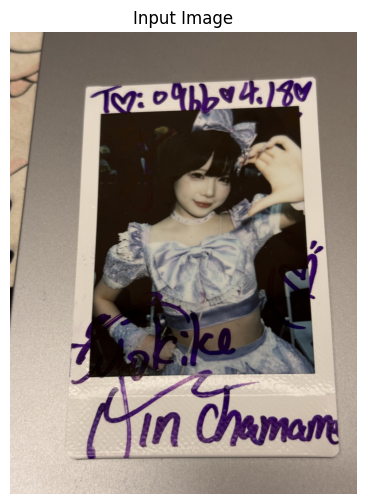

In [13]:
# 加载图片
image = Image.open("IMG_7352.jpg").convert("RGB")
image = ImageOps.exif_transpose(image)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title('Input Image')
plt.axis('off')
plt.show()


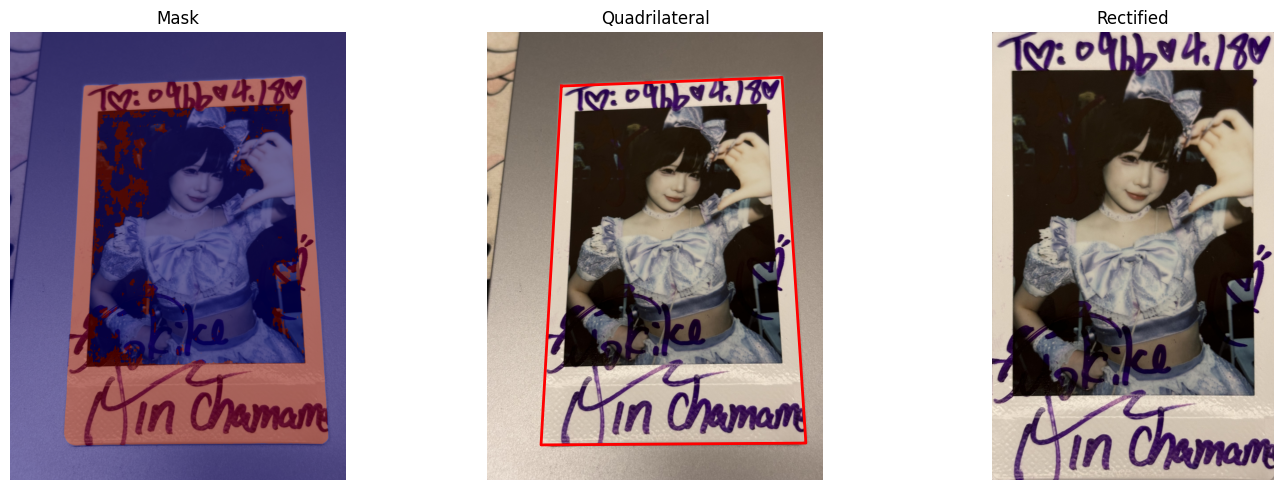

纸框顶点: [[ 666  483]
 [2654  405]
 [2869 3698]
 [ 483 3715]]
矫正尺寸: (1272, 800, 3)


In [14]:
# ===== 3a. SAM3 分割拍立得纸框 =====
prompt = "polaroid photo paper frame"
inputs = processor(images=image, text=prompt, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)

results = processor.post_process_instance_segmentation(
    outputs, threshold=0.4, mask_threshold=0.5, target_sizes=[image.size[::-1]]
)[0]
paper_mask = results["masks"][0].cpu().numpy()

# ===== 3b. 轮廓提取 =====
contours, _ = cv2.findContours(
    paper_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
)
points = np.vstack([c.reshape(-1, 2) for c in contours])

# ===== 3c. 四边形拟合（排除内部点） =====
hull = ConvexHull(points)
hull_pts = points[hull.vertices]

# 迭代最远点法 → 近似角点
p1 = hull_pts[np.argmin(hull_pts[:, 0])]
p2 = hull_pts[np.argmax(np.sum((hull_pts - p1) ** 2, axis=1))]
v = p2 - p1
signed = (v[0] * (hull_pts[:, 1] - p1[1]) - v[1] * (hull_pts[:, 0] - p1[0])) / np.linalg.norm(v)
approx = np.array([p1, p2, hull_pts[np.argmax(signed)], hull_pts[np.argmin(signed)]])
# 按绕中心的极角排序，确保四边形顶点顺序正确（避免蝴蝶形自交）
approx = approx[np.argsort(np.arctan2(
    approx[:, 1] - approx.mean(axis=0)[1],
    approx[:, 0] - approx.mean(axis=0)[0]
))]

# 收缩 + 排除内部点
center = approx.mean(axis=0)
shrunk = approx + 0.03 * (center - approx)
inside = _points_inside_quad(points, shrunk)  # 使用下方定义的工具函数
exterior = points[~inside]

# QuadrilateralFitter
fitter = QuadrilateralFitter(polygon=exterior)
paper_vertices = np.array(fitter.fit(), dtype=np.float64)
paper_vertices = paper_vertices[np.argsort(np.arctan2(
    paper_vertices[:, 1] - paper_vertices.mean(axis=0)[1],
    paper_vertices[:, 0] - paper_vertices.mean(axis=0)[0]
))]

# ===== 3d. 透视矫正 =====
src = paper_vertices.astype(np.float32)
w, h = 800, 1272  # 宽高比 1:1.59
dst = np.array([[0, 0], [w, 0], [w, h], [0, h]], dtype=np.float32)
M = cv2.getPerspectiveTransform(src, dst)
rectified_paper = cv2.warpPerspective(np.array(image), M, (w, h))
# 同步 warp 一个全1掩码 → 0=超出源图边界的缺失像素
valid_mask = cv2.warpPerspective(
    np.ones(np.array(image).shape[:2], dtype=np.uint8), M, (w, h)
).astype(bool)

# ===== 3e. 可视化 =====
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image); axes[0].set_title('Mask'); axes[0].axis('off')
axes[0].imshow(paper_mask, cmap='jet', alpha=0.5)

axes[1].imshow(image); axes[1].set_title('Quadrilateral'); axes[1].axis('off')
x = list(paper_vertices[:, 0]) + [paper_vertices[0, 0]]
y = list(paper_vertices[:, 1]) + [paper_vertices[0, 1]]
axes[1].plot(x, y, 'r-', lw=2)

axes[2].imshow(rectified_paper); axes[2].set_title('Rectified'); axes[2].axis('off')
plt.tight_layout(); plt.show()

print(f"纸框顶点: {paper_vertices.astype(int)}")
print(f"矫正尺寸: {rectified_paper.shape}")


已加载矫正图片: 4920×7824


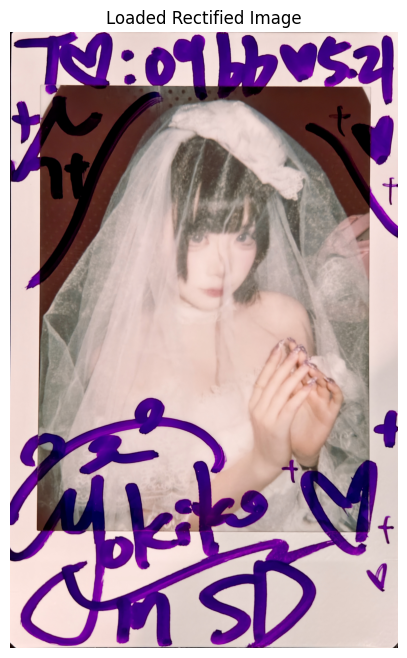

In [33]:
# ===== 快捷入口：直接读取已矫正图片 =====
# 跳过 Cell 3（纸框检测+矫正），直接加载一张已矫正的拍立得图片
# 运行此 Cell 后接着运行 Cell 4（图像区域检测）即可继续流水线

import cv2
rectified_paper = cv2.cvtColor(cv2.imread("bf3382003ea97823491e652f48d1c7e4.jpg"), cv2.COLOR_BGR2RGB)
rectified_pil = Image.fromarray(rectified_paper)

print(f"已加载矫正图片: {rectified_paper.shape[1]}×{rectified_paper.shape[0]}")

plt.figure(figsize=(6, 8))
plt.imshow(rectified_paper)
plt.title('Loaded Rectified Image')
plt.axis('off')
plt.show()

角点平均偏差: 4093.7 px | 几何质量: 0.975


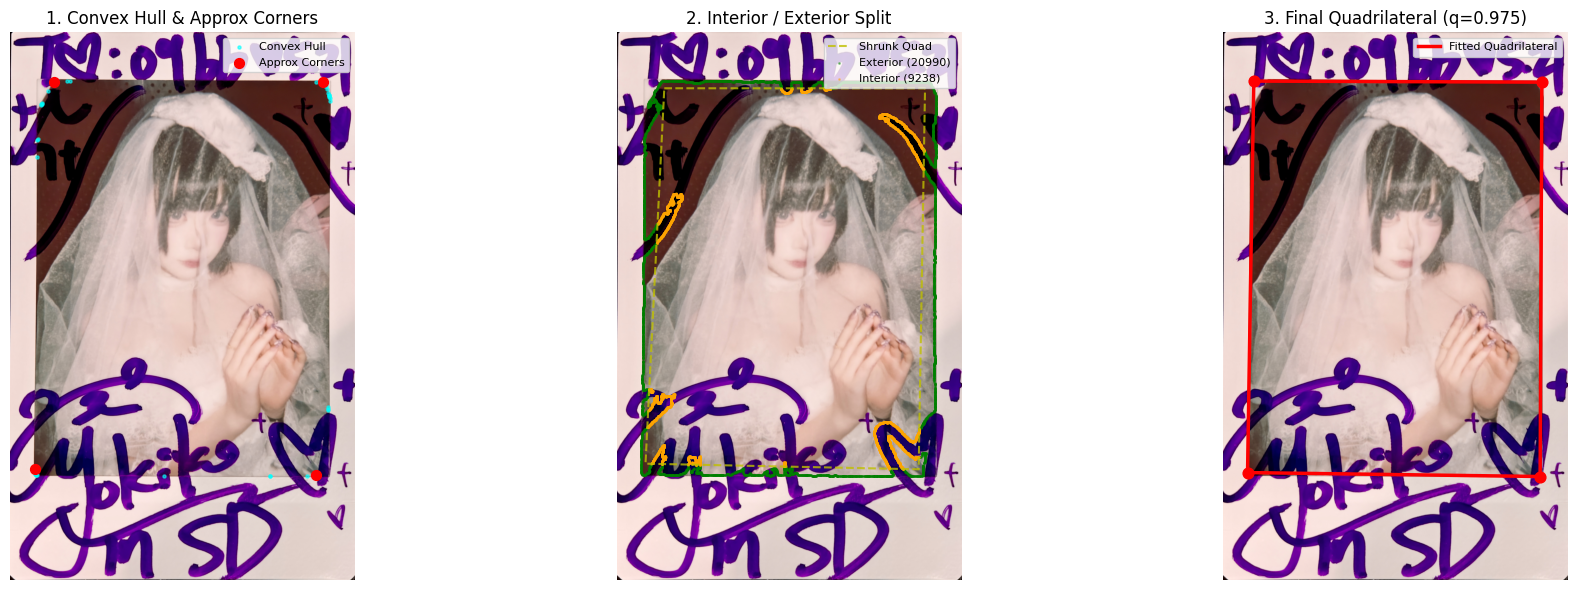

图像区域顶点: [[ 438  696]
 [4553  711]
 [4529 6345]
 [ 349 6289]], 质量: 0.975


In [34]:
# ===== 4a. SAM3 分割图像区域 =====
rectified_pil = Image.fromarray(rectified_paper)
prompt = "the image area of the polaroid photo"
inputs = processor(images=rectified_pil, text=prompt, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)

results = processor.post_process_instance_segmentation(
    outputs, threshold=0.4, mask_threshold=0.5, target_sizes=[rectified_pil.size[::-1]]
)[0]
area_mask = results["masks"][0].cpu().numpy()

# ===== 4b. 轮廓 → 四边形拟合 =====
contours, _ = cv2.findContours(
    area_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
)
points = np.vstack([c.reshape(-1, 2) for c in contours])

# ConvexHull + 近似 + 排除内部 → QuadrilateralFitter
hull = ConvexHull(points)
hull_pts = points[hull.vertices]
p1 = hull_pts[np.argmin(hull_pts[:, 0])]
p2 = hull_pts[np.argmax(np.sum((hull_pts - p1)**2, axis=1))]
v = p2 - p1
signed = (v[0]*(hull_pts[:,1]-p1[1]) - v[1]*(hull_pts[:,0]-p1[0])) / np.linalg.norm(v)
approx = np.array([p1, p2, hull_pts[np.argmax(signed)], hull_pts[np.argmin(signed)]])
# 按绕中心的极角排序，确保四边形顶点顺序正确（避免蝴蝶形自交）
approx = approx[np.argsort(np.arctan2(
    approx[:, 1] - approx.mean(axis=0)[1],
    approx[:, 0] - approx.mean(axis=0)[0]
))]
shrunk = _shrink_quad(approx, 0.03)
inside = _points_inside_quad(points, shrunk)
exterior = points[~inside]

fitter = QuadrilateralFitter(polygon=exterior)
area_vertices = np.array(fitter.fit(), dtype=np.float64)
area_vertices = area_vertices[np.argsort(np.arctan2(
    area_vertices[:,1]-area_vertices.mean(axis=0)[1],
    area_vertices[:,0]-area_vertices.mean(axis=0)[0]
))]

# ===== 4c. 透视矫正 + 质量 =====
# 固定尺寸拍立得 (800×1272) 的图像区域期望位置
# 标准拍立得上边距小、下边距大（底部留白写字）
EXPECTED_AREA_VERTICES = np.array([
    [55, 100],   # 左上
    [745, 100],  # 右上
    [745, 1022], # 右下
    [55, 1022],  # 左下
], dtype=np.float64)

# 角点距离误差（像素）
corner_error = np.mean(np.linalg.norm(area_vertices - EXPECTED_AREA_VERTICES, axis=1))

# 质量评分（基于长宽比 + 平行度）
quality = _rectify_quality(area_vertices)

# 综合：角点误差越小、quality 越高越好
print(f"角点平均偏差: {corner_error:.1f} px | 几何质量: {quality:.3f}")

# 透视矫正
src = area_vertices.astype(np.float32)
w, h = 685, 925  # 1:1.35
dst = np.array([[0,0],[w,0],[w,h],[0,h]], dtype=np.float32)
M = cv2.getPerspectiveTransform(src, dst)
rectified_area = cv2.warpPerspective(rectified_paper, M, (w, h))
quality = _rectify_quality(area_vertices)

# ===== 4d. 可视化：三张子图（凸包+近似 / 内外点划分 / 最终四边形） =====
pts = np.asarray(points, dtype=np.float64)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 子图 1: 凸包 + 近似角点
axes[0].imshow(rectified_paper)
axes[0].scatter(hull_pts[:, 0], hull_pts[:, 1], c='cyan', s=5, alpha=0.6, label='Convex Hull')
axes[0].scatter(approx[:, 0], approx[:, 1], c='red', s=50, zorder=5, label='Approx Corners')
axes[0].set_title('1. Convex Hull & Approx Corners')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].axis('off')

# 子图 2: 内部/外部点划分
exterior_sample = exterior if len(exterior) <= 5000 else exterior[np.random.choice(len(exterior), 5000, replace=False)]
interior_pts = pts[inside]
interior_sample = interior_pts if len(interior_pts) <= 5000 else interior_pts[np.random.choice(len(interior_pts), 5000, replace=False)]

axes[1].imshow(rectified_paper)
# 收缩四边形虚线
x = list(shrunk[:, 0]) + [shrunk[0, 0]]
y = list(shrunk[:, 1]) + [shrunk[0, 1]]
axes[1].plot(x, y, 'y--', linewidth=1.5, alpha=0.8, label='Shrunk Quad')
axes[1].scatter(exterior_sample[:, 0], exterior_sample[:, 1], c='green', s=1, alpha=0.4, label=f'Exterior ({len(exterior)})')
axes[1].scatter(interior_sample[:, 0], interior_sample[:, 1], c='orange', s=1, alpha=0.4, label=f'Interior ({np.sum(inside)})')
axes[1].set_title('2. Interior / Exterior Split')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].axis('off')

# 子图 3: 最终四边形
vertices_int = area_vertices.astype(int)
axes[2].imshow(rectified_paper)
x = list(vertices_int[:, 0]) + [vertices_int[0, 0]]
y = list(vertices_int[:, 1]) + [vertices_int[0, 1]]
axes[2].plot(x, y, 'r-', linewidth=2.5, label='Fitted Quadrilateral')
axes[2].scatter(vertices_int[:, 0], vertices_int[:, 1], c='red', s=60, zorder=5)
axes[2].set_title(f'3. Final Quadrilateral (q={quality:.3f})')
axes[2].legend(loc='upper right', fontsize=8)
axes[2].axis('off')
plt.tight_layout(); plt.show()
print(f"图像区域顶点: {area_vertices.astype(int)}, 质量: {quality:.3f}")


白平衡增益: R=1.014 G=1.090 B=1.113 → 目标 (240,240,240)
真正缺失像素（warp 超出源图边界）: 0
缺失区域掩码已保存: missing_region_mask.png


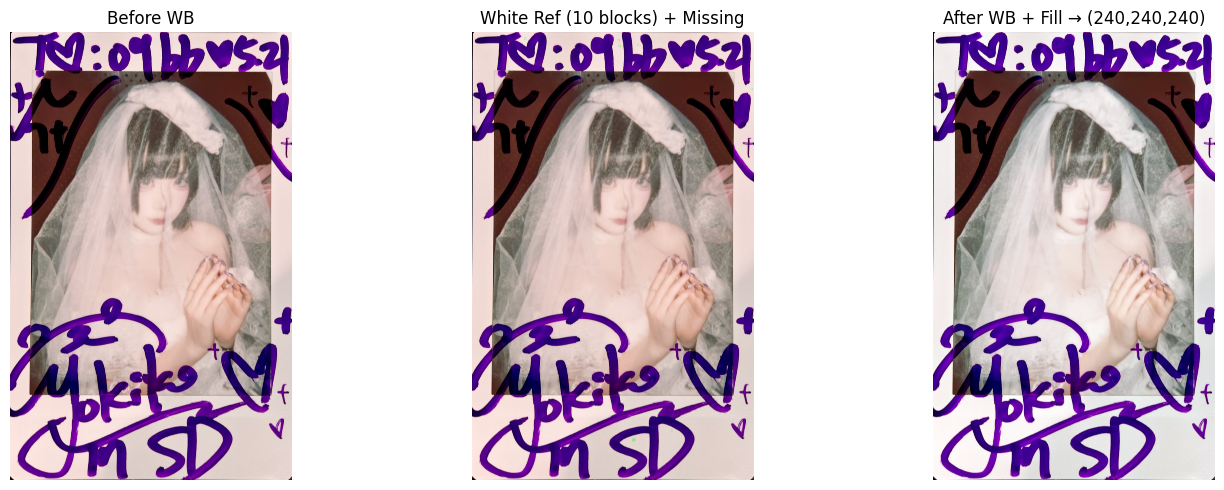

In [35]:
# ===== 5a. 生成边框掩码 =====
h, w = rectified_paper.shape[:2]
border_mask = np.ones((h, w), dtype=np.uint8)

margin = 5
inner = np.array([
    [area_vertices[0][0]-margin, area_vertices[0][1]-margin],
    [area_vertices[1][0]+margin, area_vertices[1][1]-margin],
    [area_vertices[2][0]+margin, area_vertices[2][1]+margin],
    [area_vertices[3][0]-margin, area_vertices[3][1]+margin]
], dtype=np.int32)
cv2.fillPoly(border_mask, [inner], 0)
border_mask = border_mask.astype(bool)

# ===== 5b. 寻找白色参考区域 =====
img_arr = np.array(rectified_pil)
is_bright = np.all(img_arr > 170, axis=2)
is_neutral = np.std(img_arr.astype(np.float32), axis=2) < 25
is_white = is_bright & is_neutral & border_mask

blocks = []
for y in range(0, h-32, 16):
    for x in range(0, w-32, 16):
        block = is_white[y:y+32, x:x+32]
        if np.sum(block) / 1024 > 0.8:
            pixels = img_arr[y:y+32, x:x+32][block]
            blocks.append({'x': x, 'y': y, 'mean': pixels.mean(axis=0), 'var': pixels.var(axis=0).mean()})

if blocks:
    blocks.sort(key=lambda b: b['var'])
    best = blocks[:10]
    ref_white = np.mean([b['mean'] for b in best], axis=0)
    target = 240.0  # 固定目标白色 (240, 240, 240)
    gains = np.array([target/ref_white[0], target/ref_white[1], target/ref_white[2]])
    wb_image = np.clip(img_arr.astype(np.float32) * gains, 0, 255).astype(np.uint8)
    print(f"白平衡增益: R={gains[0]:.3f} G={gains[1]:.3f} B={gains[2]:.3f} → 目标 (240,240,240)")
else:
    wb_image = img_arr.copy()
    best = []
    target = 240.0
    print("未找到白色参考区域，跳过白平衡")

# ===== 5c. 检测真正的缺失区域（warpPerspective 超出源图边界） =====
# 用 Cell 3 中同步 warp 的 valid_mask —— 0=源图范围外的缺失像素，精确不误伤
missing_mask = ~valid_mask

# 膨胀覆盖交界处黑线及暗边过渡
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
missing_mask = cv2.dilate(missing_mask.astype(np.uint8), kernel).astype(bool)

true_missing = missing_mask.sum()
print(f"真正缺失像素（warp 超出源图边界）: {true_missing}")

if missing_mask.any():
    wb_image[missing_mask] = (240, 240, 240)
    print(f"填充了 {true_missing} 个缺失像素 → (240, 240, 240)")

# 保存缺失区域掩码
cv2.imwrite("missing_region_mask.png", (missing_mask.astype(np.uint8) * 255))
print("缺失区域掩码已保存: missing_region_mask.png")

# ===== 5d. 可视化 =====
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rectified_pil); axes[0].set_title('Before WB'); axes[0].axis('off')

# 白参考块（绿框）+ 缺失区域（红）
vis = np.array(rectified_pil).copy()
for b in best:
    cv2.rectangle(vis, (b['x'], b['y']), (b['x']+32, b['y']+32), (0, 255, 0), 2)
if missing_mask.any():
    vis[missing_mask] = (255, 0, 0)
axes[1].imshow(vis); axes[1].set_title(f'White Ref ({len(best)} blocks) + Missing'); axes[1].axis('off')

axes[2].imshow(wb_image); axes[2].set_title(f'After WB + Fill → (240,240,240)'); axes[2].axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# ===== 6. 自适应墨迹提取（handwriting + scribble） =====
wb_pil = Image.fromarray(wb_image)
H, W = wb_image.shape[:2]

image_region = np.zeros((H, W), dtype=np.uint8)
cv2.fillPoly(image_region, [area_vertices.astype(int)], 1)
image_region = image_region.astype(bool)
border_region = ~image_region

target_prompts = ["handwriting", "scribble"]
all_masks_14x8 = {}

THRESHOLDS = [0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05]

for pn in target_prompts:
    all_masks_14x8[pn] = []
    inputs = processor(images=wb_pil, text=pn, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    for th in tqdm.tqdm(THRESHOLDS):
        res = processor.post_process_instance_segmentation(
            outputs, threshold=th, mask_threshold=0.5,
            target_sizes=[wb_pil.size[::-1]]
        )[0]
        if len(res["masks"]) == 0:
            all_masks_14x8[pn].append(np.zeros((H, W), dtype=bool))
        else:
            masks = res["masks"].cpu().numpy()
            masks = masks[~(np.mean(masks, axis=(1,2)) > 0.5)]
            all_masks_14x8[pn].append(np.any(masks, axis=0))

print("两个 prompt 的 8 阈值 mask 已获取")

def select_by_area_growth(masks_list):
    areas = [m.mean() for m in masks_list]
    growths = []
    for i in range(1, len(areas)):
        if areas[i-1] > 0: growths.append((areas[i]-areas[i-1])/areas[i-1])
        else: growths.append(0 if areas[i]==0 else 999)
    for i, g in enumerate(growths):
        if g < 0.15 and areas[i+1] > 0.01: return i+1
    for i in range(len(areas)-1, -1, -1):
        if areas[i] > 0.01: return i
    return 0

final_masks = {}

for pn in target_prompts:
    print(f"\n{'='*60}")
    print(f"  {pn}")
    print(f"{'='*60}")
    
    masks_list = all_masks_14x8[pn]
    pred_ti = select_by_area_growth(masks_list)
    offsets = [0, 1, 2] if pn == "handwriting" else [-1, 0, 1, 2]
    
    candidates = []
    for off in offsets:
        ti = pred_ti + off
        if 0 <= ti < len(THRESHOLDS):
            candidates.append((ti, THRESHOLDS[ti], masks_list[ti]))
    
    print(f"预测点 t={THRESHOLDS[pred_ti]}, 候选: {[t for _,t,_ in candidates]}")
    
    accepted = candidates[0][2].copy()
    accepted_ti = candidates[0][0]
    
    ref_pixels = wb_image[accepted]
    if ref_pixels.size > 0:
        ink_mean = ref_pixels.mean(axis=0)
        ink_std = ref_pixels.std(axis=0) + 1e-6
    else:
        ink_mean = np.array([0, 0, 0]); ink_std = np.array([1, 1, 1])
    
    print(f"初始面积: {accepted.sum()} px")
    print(f"墨迹颜色: mean=({ink_mean[0]:.0f},{ink_mean[1]:.0f},{ink_mean[2]:.0f})")
    
    border_ink = wb_image[accepted & border_region]
    if border_ink.size > 0:
        border_mean, border_std = border_ink.mean(axis=0), border_ink.std(axis=0) + 1e-6
    else:
        border_mean, border_std = ink_mean, ink_std
    
    for idx in range(1, len(candidates)):
        prev_ti, prev_t, prev_mask = candidates[idx - 1]
        cur_ti, cur_t, cur_mask = candidates[idx]
        
        new_pixels = cur_mask & ~prev_mask
        n_new = new_pixels.sum()
        
        if n_new < 100:
            print(f"\n  t={cur_t}: 新增 {n_new} px (<100, 自动接受)")
            accepted = cur_mask; accepted_ti = cur_ti
            ref_pixels = wb_image[accepted]
            if ref_pixels.size > 0: ink_mean = ref_pixels.mean(axis=0); ink_std = ref_pixels.std(axis=0) + 1e-6
            continue
        
        new_border = new_pixels & border_region
        new_image = new_pixels & image_region
        
        match_border = 0
        match_image = 0
        if new_border.sum() > 0:
            b_z = np.abs((wb_image[new_border].astype(float) - border_mean) / border_std)
            match_border = (b_z.mean(axis=1) < 2.0).sum()
        if new_image.sum() > 0:
            i_z = np.abs((wb_image[new_image].astype(float) - ink_mean) / ink_std)
            match_image = (i_z.mean(axis=1) < 3.0).sum()
        
        total_match = match_border + match_image
        match_ratio = total_match / n_new
        
        print(f"\n  t={cur_t}: 新增 {n_new} px "
              f"(边框 {new_border.sum()}:{match_border} 图像 {new_image.sum()}:{match_image}) "
              f"匹配率={match_ratio:.2f}")
        
        # 可视化
        fig, axes = plt.subplots(1, 3, figsize=(14, 5))
        axes[0].imshow(wb_image); axes[0].imshow(cur_mask, cmap='viridis', alpha=0.4)
        axes[0].set_title(f'{pn} t={cur_t} ({cur_mask.sum()} px)', fontsize=9); axes[0].axis('off')
        
        overlay = (wb_image * 0.3).astype(np.uint8)
        overlay[prev_mask] = [120, 120, 120]
        new_match = np.zeros_like(new_pixels)
        if new_border.sum() > 0:
            b_z = np.abs((wb_image[new_border].astype(float) - border_mean) / border_std)
            new_match[new_border] = (b_z.mean(axis=1) < 2.0)
        if new_image.sum() > 0:
            i_z = np.abs((wb_image[new_image].astype(float) - ink_mean) / ink_std)
            new_match[new_image] = (i_z.mean(axis=1) < 3.0)
        overlay[new_pixels & new_match] = [0, 220, 0]
        overlay[new_pixels & ~new_match] = [255, 40, 40]
        axes[1].imshow(overlay)
        axes[1].set_title(f'New: green=match red=mismatch ({match_ratio:.0%})', fontsize=9); axes[1].axis('off')
        
        axes[2].imshow(wb_image); axes[2].imshow(cur_mask, cmap='viridis', alpha=0.4)
        decision = "ACCEPT" if match_ratio >= 0.70 else "REJECT"
        axes[2].set_title(f'{decision}', fontsize=11, color='green' if decision=='ACCEPT' else 'red', fontweight='bold')
        axes[2].axis('off')
        plt.tight_layout(); plt.show()
        
        if match_ratio >= 0.70:
            accepted = cur_mask; accepted_ti = cur_ti
            ref_pixels = wb_image[accepted]
            if ref_pixels.size > 0: ink_mean = ref_pixels.mean(axis=0); ink_std = ref_pixels.std(axis=0) + 1e-6
            print(f"  OK 接受 → 面积 {accepted.sum()} px")
        else:
            print(f"  X 拒绝，停止 → 最终 t={THRESHOLDS[accepted_ti]}")
            break
    
    final_masks[pn] = accepted
    print(f"\n  {pn} 最终: t={THRESHOLDS[accepted_ti]} area={accepted.sum()} px")

# ---- 最终对比 ----
print(f"\n{'='*60}")
print("  最终结果（仅提取的墨迹像素）")
print(f"{'='*60}")

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes[0].imshow(wb_image); axes[0].set_title('White-balanced'); axes[0].axis('off')
h_extracted = wb_image.copy(); h_extracted[~final_masks['handwriting']] = 255
axes[1].imshow(h_extracted); axes[1].set_title(f"handwriting ({final_masks['handwriting'].sum()} px)"); axes[1].axis('off')
s_extracted = wb_image.copy(); s_extracted[~final_masks['scribble']] = 255
axes[2].imshow(s_extracted); axes[2].set_title(f"scribble ({final_masks['scribble'].sum()} px)"); axes[2].axis('off')
plt.tight_layout(); plt.show()

inter = final_masks['handwriting'] & final_masks['scribble']
i_extracted = wb_image.copy(); i_extracted[~inter] = 255
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 6))
axes2[0].imshow(wb_image); axes2[0].set_title('WB'); axes2[0].axis('off')
axes2[1].imshow(i_extracted); axes2[1].set_title(f'Intersection ({inter.sum()} px)'); axes2[1].axis('off')
plt.tight_layout(); plt.show()

print(f"handwriting: {final_masks['handwriting'].sum()} px")
print(f"scribble:    {final_masks['scribble'].sum()} px")
print(f"intersection: {inter.sum()} px (高置信共识)")

  0%|          | 0/8 [00:00<?, ?it/s]

In [1]:
# ===== 释放 CUDA 显存 =====
import gc
del all_masks_14x8, outputs, inputs
gc.collect()
torch.cuda.empty_cache()
print(f"CUDA 显存已释放，当前分配: {torch.cuda.memory_allocated() / 1024**2:.0f} MB / 缓存: {torch.cuda.memory_reserved() / 1024**2:.0f} MB")

NameError: name 'all_masks_14x8' is not defined

In [ ]:
torch.cuda.empty_cache()
print(f"CUDA 显存已释放，当前分配: {torch.cuda.memory_allocated() / 1024**2:.0f} MB / 缓存: {torch.cuda.memory_reserved() / 1024**2:.0f} MB")

NameError: name 'torch' is not defined